In [ ]:
import sys
sys.path.append('../../../../src')
sys.path.append('../../../..')

import os

from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from converters.tile.bin_1d import Tile2Symb1dBin

from tests.experimental.test_loop import Params, test_loop

SYMBOLS = get_asciis()
FONT_PATH = "../../../../fonts/Inconsolata-Regular.ttf"
FONT_SIZE = 10
MAX_WIDTH = 30
MAX_HEIGHT = 9
IMG_SET_PATH = "../../../../imgs/BSDS500"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:10]]


def make_converter(params: Params):
    return Tile2Symb1dBin(
        symbols=SYMBOLS,
        font=ImageFont.truetype(params.font_path, params.font_size),
        **params.converter_args)

Min: -0.0153 | Max: 0.0684 | Mean: 0.0247 | Std: 0.0252
Min: -0.0011 | Max: 0.1095 | Mean: 0.0699 | Std: 0.0355
Min: 0.0361 | Max: 0.1306 | Mean: 0.0827 | Std: 0.0331
Min: 0.0297 | Max: 0.1395 | Mean: 0.0787 | Std: 0.0355
Min: 0.0281 | Max: 0.1379 | Mean: 0.0771 | Std: 0.0342
Min: 0.0247 | Max: 0.1504 | Mean: 0.0784 | Std: 0.0384
Min: 0.0140 | Max: 0.1567 | Mean: 0.0780 | Std: 0.0395
Min: 0.0313 | Max: 0.1453 | Mean: 0.0824 | Std: 0.0364
Min: 0.0340 | Max: 0.1489 | Mean: 0.0845 | Std: 0.0370


C:\Users\wojte\AppData\Local\Temp\ipykernel_3248\4009546293.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


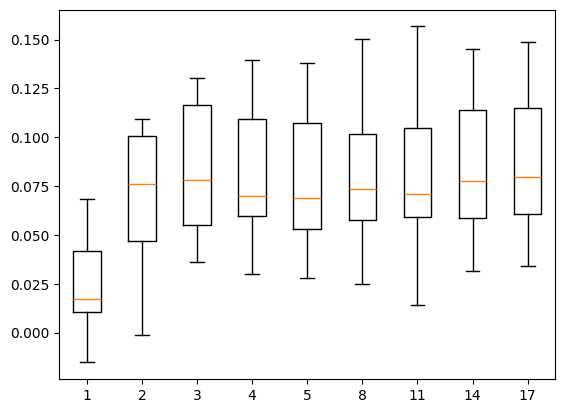

In [2]:
# bins

params_space = [
    bins for bins in range(1, 5, 1)
]
params_space += [
    bins for bins in range(5, 18, 3)
]

params_space = list(
    map(lambda bins: Params(
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={'bins': bins},
        preprocess_args={}),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.converter_args['bins'] for param in params_space])
plt.show()

Min: -0.0023 | Max: 0.1093 | Mean: 0.0504 | Std: 0.0356
Min: 0.0079 | Max: 0.1297 | Mean: 0.0745 | Std: 0.0391
Min: 0.0455 | Max: 0.1608 | Mean: 0.0929 | Std: 0.0337
Min: 0.0518 | Max: 0.1790 | Mean: 0.1076 | Std: 0.0381
Min: 0.0537 | Max: 0.1935 | Mean: 0.1129 | Std: 0.0413


C:\Users\wojte\AppData\Local\Temp\ipykernel_3248\549677722.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


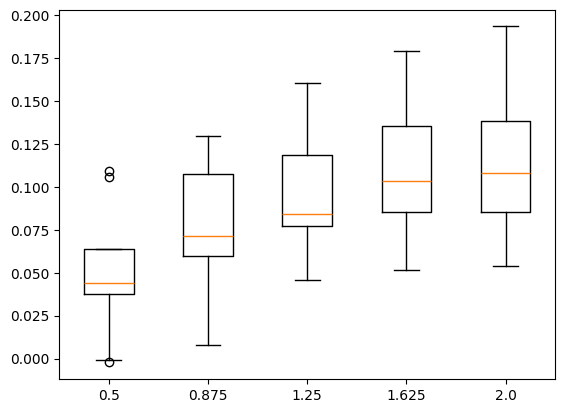

In [3]:
# contrast

params_space = [
    {'contrast': c} for c in np.linspace(0.5, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda preprocess_args: Params(
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args=preprocess_args),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.preprocess_args['contrast'] for param in params_space])
plt.show()

In [4]:
import math
from PIL import Image
from image.processing import preprocess_img
from rendering.terminal import print_gallery


converter = Tile2Symb1dBin(symbols=SYMBOLS,
                           font=ImageFont.truetype(FONT_PATH, FONT_SIZE))

results = []
for img_path in IMG_PATHS[:5]:
    img = Image.open(img_path).convert("L")
    img = preprocess_img(img, contrast=1.7)
    win_w = math.ceil(MAX_WIDTH / img.width)
    win_h = win_w * 2
    if MAX_WIDTH:
        scale_w = MAX_WIDTH * win_w / img.width
    if MAX_HEIGHT:
        scale_h = MAX_HEIGHT * win_h / img.height
    img = preprocess_img(img, scale_factor=min(scale_h, scale_w))
    res_arr = converter.process_image(img, (win_w, win_h))
    results.append(res_arr)

print_gallery(results, 2)

---------------------------------------------------------------
 | ~""^//!!v+<?/""=|i11^""^^-- | <4XeUddw4x*cWehqH80M09?5N8# | 
 | ~_,,;'_^\":'-----_--`` . `  | 1?(1?ID]5L!^ZtV6Kz5whA+lbi" | 
 | 5UXKW@K888WHKH8@8@%%kd#4haC | ~'"^<nh#wyc_^-;1iTx^^\^/"^^ | 
 | A%DpHHKH698HHWK8W@WKWE9EdSn | r(c7twUhT;'^;` `:)?i>lllT<r | 
 | SU8@WQk,:,:')dW8@KW88Kk6PZu | )?v+TIOEkF^`. `.-fITJ}fVVf* | 
 | SmmWW#{)J5tff#H@KH%UZZSw5AF | |(]L+]OZhAx;`-``,AJ2Cof=)r^ | 
 | 24wU6bP9XXmWHPDm%9#kpDZ45CT | "xL{ljCA5w],..-._TxLahSuT+^ | 
 | XkK@gQ&0KKQ0&MNBN8K#Xp5ZFVf | i7}{}CZSwwe" ..;v=""}x{TCJ< | 
 | 4W8&BBMKM0B&WH88WXO%#%hZYnl | ++>)<xe23hh"--1t*---:^>}i+/ | 
---------------------------------------------------------------
 | LfVjYl|^;:,;"()?v\1>]4Fi~-- |  `  .------- | 
 | ^^"^^^'_,^"^=|*^"^:^~------ | :,_'^^,__;,~ | 
 | *!!!/!|^/!"^|1\|""^^^^^":^" | Tl{xxxtTLJTJ | 
 | =r//cT|l5uFZHKXhZoi|SwHEk8x | lxV[J2ftyf}x | 
 | ?=*v1^riLT(=i2tlcT}7T+"^Vl1 | leuj\/r"YenY | 
 | ((/r*1" --""!c<**/1=^"^-/ ` | fVay^--`!3t7 | 
 |